<a href="https://colab.research.google.com/github/daniel-usp/USP/blob/main/Previs%C3%A3o_Crise_Financeira_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍📊 Macroeconomia & Inteligência Artificial: Previsão de Crises Financeiras

A interseção entre **Macroeconomia** e **Inteligência Artificial (IA)** está se tornando cada vez mais promissora. A IA oferece métodos poderosos para compreender e prever variáveis agregadas da economia, como ciclos econômicos, políticas monetárias e diversos indicadores econômicos. Utilizando algoritmos de **Machine Learning**, economistas podem analisar grandes volumes de dados para identificar padrões e tendências, fornecendo insights valiosos.

O **Python**, com suas bibliotecas especializadas em IA, torna o processo de análise e modelagem mais acessível e eficiente. Ao aplicar técnicas de IA na Macroeconomia, podemos melhorar significativamente nossa compreensão dos fenômenos econômicos e a precisão de nossas previsões, abrindo novas oportunidades para análise e tomada de decisões.

## 🤖 IA e Machine Learning

A **Inteligência Artificial (IA)** é um campo da ciência da computação que desenvolve sistemas capazes de realizar tarefas que normalmente exigiriam inteligência humana. Essas tarefas incluem reconhecimento de padrões, aprendizado, raciocínio, resolução de problemas, compreensão da linguagem natural e interação com o ambiente.

### 💡 IA Aprendizado de Máquina (Machine Learning)

Entre as várias abordagens da IA, uma que se destaca na economia é o **Aprendizado de Máquina (Machine Learning)**. Esta área envolve algoritmos que permitem que sistemas aprendam a partir de dados sem serem explicitamente programados. Existem várias técnicas de aprendizado de máquina:

- **Aprendizado Supervisionado**
- **Aprendizado Não Supervisionado**
- **Aprendizado por Reforço**

Essas técnicas são usadas para previsão de dados, reconhecimento de padrões, classificação e recomendação, entre outras aplicações.

### 🔍 Modelos Macroeconômicos Tradicionais vs. IA

Modelos macroeconômicos tradicionais geralmente dependem de suposições simplificadas e relações lineares. No entanto, a economia é um sistema complexo e interconectado, com muitas variáveis influenciando umas às outras de maneiras não-lineares. A IA e o Machine Learning são ferramentas que lidam melhor com essa complexidade, permitindo previsões mais precisas e sofisticadas.

## 🔮 Prevendo a Probabilidade de Recessão

Para ilustrar o uso do Machine Learning na previsão macroeconômica, criamos modelos para prever a probabilidade de recessão nos Estados Unidos. Vamos utilizar três algoritmos de Machine Learning:

### 🌳 Random Forest
- **Descrição:** Random Forest cria uma "floresta" de árvores de decisão a partir de amostras aleatórias do conjunto de dados.
- **Funcionamento:** Cada árvore vota em uma classe ou fornece uma previsão contínua, e a decisão final é baseada na média das previsões.
- **Vantagens:** Eficaz em reduzir overfitting e fornecer estimativas de importância das características.

### 🤝 KNN (K-Nearest Neighbors)
- **Descrição:** Algoritmo simples usado para classificação e regressão.
- **Funcionamento:** Faz previsões baseadas na proximidade dos pontos de dados mais próximos no espaço de características.
- **Vantagens:** Fácil de entender e implementar, mas pode ser computacionalmente caro para grandes conjuntos de dados.

### 📈 Regressão Logística
- **Descrição:** Algoritmo de classificação binária que prevê a probabilidade de um dado pertencer a uma classe específica.
- **Funcionamento:** Utiliza uma função logística para modelar a relação entre as características de entrada e a probabilidade de pertencer a uma classe.
- **Vantagens:** Simples e eficaz para problemas de classificação binária.

## 🔢 Variáveis Utilizadas

Vamos utilizar as seguintes variáveis para a previsão:

- **Taxa de Juros** (Curto: 3 meses, Longo: 10 anos)
- **Emprego** (Excluindo agrícolas)
- **Inflação**
- **Diferença de Taxa de Juros** (Curva de juros)

Além disso, incluímos lags de 3, 6, 9 e 12 meses para as variáveis explicativas. Nosso objetivo é prever se haverá uma recessão nos 12 meses subsequentes, utilizando o indicador de recessão mensal do NBER.

---

Essa abordagem nos permitirá explorar como a IA pode melhorar a análise macroeconômica, oferecendo previsões mais precisas e insights valiosos. 🚀📉


# 1. Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
sns.set()

# 2. Dados

Utilizaremos uma variação do cross validation que ao invés de ordenar os dados aleatóriamente, ordena sequencialmente no tempo.

Utilizaremos os seguintes modelos: Lasso, Random forest e KNN. Todos estão sendo aplicados com o uso do pacote caret, que possibilita um uso uniforme de centenas de algoritmos de machine learning.

### Explicação do Código - 2. Dados

Este código realiza a coleta e o tratamento de dados econômicos obtidos do Federal Reserve Economic Data (FRED) utilizando a biblioteca `pandas_datareader`. A seguir, explico cada etapa do código:

1. **Seleção dos Tickers:**

    ```python
    tickers = ["USREC", "GS10", "TB3MS", "PAYEMS", "CPIAUCSL"]
    ```

    - Define a lista de séries temporais a serem coletadas. Os tickers representam:
        - `USREC`: Indicador de recessão nos EUA.
        - `GS10`: Taxa de juros de títulos do Tesouro dos EUA com vencimento em 10 anos.
        - `TB3MS`: Taxa de juros de títulos do Tesouro dos EUA com vencimento em 3 meses.
        - `PAYEMS`: Emprego não agrícola.
        - `CPIAUCSL`: Índice de Preços ao Consumidor para Todos os Consumidores Urbanos.

2. **Coleta de Dados do FRED:**

    ```python
    data_raw = pdr.get_data_fred(tickers, start = "1975-01-01")
    ```

    - Coleta as séries temporais do FRED a partir de 1º de janeiro de 1975.

3. **Tratamento dos Dados:**

    ```python
    data = (
        data_raw
        .assign(slope_yield=data_raw["GS10"] - data_raw["TB3MS"])
        .assign(USREC=data_raw["USREC"].shift(-12).astype("category"))
        .assign(GS10_lag3=data_raw["GS10"].shift(3))
        .assign(GS10_lag6=data_raw["GS10"].shift(6))
        .assign(GS10_lag9=data_raw["GS10"].shift(9))
        .assign(GS10_lag12=data_raw["GS10"].shift(12))
        .loc["1980":"2022"]
        .reset_index(names = 'date')
    )
    ```

    - **Criação da inclinação da curva de juros (`slope_yield`)**: Calcula a diferença entre as taxas de juros dos títulos de 10 anos (`GS10`) e de 3 meses (`TB3MS`).
    - **Ajuste da variável `USREC`**: Desloca a variável de recessão `USREC` em 12 meses para frente, categorizando-a.
    - **Criação de variáveis defasadas (`lag`)**: Cria novas colunas para as taxas de juros de 10 anos com defasagens de 3, 6, 9 e 12 meses.
    - **Filtragem e reindexação**: Limita os dados ao período entre 1980 e 2020 e redefine o índice com o nome `date`.


In [ ]:
# Selecionar os tickers
tickers = ["USREC", "GS10", "TB3MS", "PAYEMS", "CPIAUCSL"]

# Coletar os dados do FRED usando pandas_datareader
data_raw = pdr.get_data_fred(tickers, start = "1975-01-01")

# Realizar os tratamentos
data = (
    data_raw
    .assign(slope_yield=data_raw["GS10"] - data_raw["TB3MS"])
    .assign(USREC=data_raw["USREC"].shift(-12).astype("category"))
    .assign(GS10_lag3=data_raw["GS10"].shift(3))
    .assign(GS10_lag6=data_raw["GS10"].shift(6))
    .assign(GS10_lag9=data_raw["GS10"].shift(9))
    .assign(GS10_lag12=data_raw["GS10"].shift(12))
    .loc["1980":"2020"]
    .reset_index(names = 'date')
)

In [ ]:
data

,date,USREC,GS10,TB3MS,PAYEMS,CPIAUCSL,slope_yield,GS10_lag3,GS10_lag6,GS10_lag9,GS10_lag12
0,1980-01-01,0.0,10.80,12.00,90800,78.000,-1.20,10.30,8.95,9.18,9.10
1,1980-02-01,0.0,12.41,12.86,90883,79.000,-0.45,10.65,9.03,9.25,9.10
2,1980-03-01,0.0,12.75,15.20,90994,80.100,-2.45,10.39,9.33,8.91,9.12
3,1980-04-01,0.0,11.47,13.20,90849,80.900,-1.73,10.80,10.30,8.95,9.18
4,1980-05-01,0.0,10.18,8.58,90420,81.700,1.60,12.41,10.65,9.03,9.25
...,...,...,...,...,...,...,...,...,...,...,...
487,2020-08-01,0.0,0.65,0.10,140774,259.366,0.55,0.67,1.50,1.81,1.63
488,2020-09-01,0.0,0.68,0.11,141820,259.951,0.57,0.73,0.87,1.86,1.70
489,2020-10-01,0.0,0.79,0.10,142493,260.249,0.69,0.62,0.66,1.76,1.71
490,2020-11-01,0.0,0.87,0.09,142761,260.895,0.78,0.65,0.67,1.50,1.81


# 3. Modelos

### Explicação do Código

Este código realiza o treinamento e avaliação de três modelos de classificação (Regressão Logística, Random Forest e k-Nearest Neighbors) usando validação cruzada em séries temporais. A seguir, explico cada etapa do código:

1. **Definição do Objeto de Controle de Treinamento:**

    ```python
    tscv = TimeSeriesSplit(n_splits=5)
    ```

    - Define um objeto `TimeSeriesSplit` para realizar a validação cruzada em séries temporais com 5 divisões (`n_splits=5`). Esse método preserva a ordem temporal dos dados ao criar conjuntos de treino e teste, essencial para séries temporais.

2. **Definição dos Modelos de Classificação:**

    - **Regressão Logística:**
        ```python
        lr_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
        ```
        - Define um modelo de Regressão Logística com penalidade `l1`, solver `liblinear`, e até 1000 iterações.
    
    - **Random Forest:**
        ```python
        rf_model = RandomForestClassifier()
        ```
        - Define um modelo Random Forest padrão.

    - **k-Nearest Neighbors:**
        ```python
        knn_model = KNeighborsClassifier()
        ```
        - Define um modelo k-Nearest Neighbors padrão.

3. **Coleta e Tratamento de Dados:**

    - Assumimos que a coleta e tratamento dos dados já foi realizada, conforme os códigos anteriores.

4. **Definição das Variáveis Preditivas e da Variável de Resposta:**

    ```python
    X = data.drop(columns=["USREC", "date"])
    y = data["USREC"]
    ```

    - `X` contém as variáveis preditivas, exceto `USREC` (variável de resposta) e `date`.
    - `y` contém a variável de resposta, que indica a ocorrência de recessão (`USREC`).

5. **Pré-processamento: Padronização dos Dados:**

    ```python
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    ```

    - Os dados são padronizados usando `StandardScaler` para garantir que todas as variáveis preditivas tenham a mesma escala.

6. **Loop de Validação Cruzada para Treinamento e Avaliação:**

    ```python
    for train_index, test_index in tscv.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Treinar e avaliar o modelo de Regressão Logística
        lr_model.fit(X_train, y_train)
        lr_pred = lr_model.predict(X_test)
        lr_accuracy = accuracy_score(y_test, lr_pred)
        print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

        # Treinar e avaliar o modelo Random Forest
        rf_model.fit(X_train, y_train)
        rf_pred = rf_model.predict(X_test)
        rf_accuracy = accuracy_score(y_test, rf_pred)
        print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

        # Treinar e avaliar o modelo k-Nearest Neighbors
        knn_model.fit(X_train, y_train)
        knn_pred = knn_model.predict(X_test)
        knn_accuracy = accuracy_score(y_test, knn_pred)
        print(f"k-Nearest Neighbors Accuracy: {knn_accuracy:.4f}")
    ```

    - **Divisão dos Dados**: Para cada divisão criada pelo `TimeSeriesSplit`, os dados são divididos em conjuntos de treino (`X_train`, `y_train`) e teste (`X_test`, `y_test`).
    - **Treinamento e Avaliação dos Modelos**:
        - Cada modelo (Regressão Logística, Random Forest e k-Nearest Neighbors) é treinado com o conjunto de treino e avaliado no conjunto de teste.
        - A acurácia de cada modelo é calculada e exibida a cada iteração.


In [ ]:
# Definindo o objeto de controle de treinamento
tscv = TimeSeriesSplit(n_splits=5)

# Treinamento de um modelo usando Regressão Logística (LogisticRegression)
lr_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

# Treinamento de um modelo usando Random Forest (RandomForestClassifier)
rf_model = RandomForestClassifier()

# Treinamento de um modelo usando k-Nearest Neighbors (KNeighborsClassifier)
knn_model = KNeighborsClassifier()

# Coletar os dados e realizar os tratamentos (como nos códigos anteriores)

# Definir as variáveis preditoras e a variável de resposta
X = data.drop(columns=["USREC", "date"])
y = data["USREC"]

# Pré-processamento: Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Loop para realizar validação cruzada em séries temporais
for train_index, test_index in tscv.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Treinar e avaliar o modelo de Regressão Logística
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_pred)
    print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

    # Treinar e avaliar o modelo Random Forest
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_pred)
    print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

    # Treinar e avaliar o modelo k-Nearest Neighbors
    knn_model.fit(X_train, y_train)
    knn_pred = knn_model.predict(X_test)
    knn_accuracy = accuracy_score(y_test, knn_pred)
    print(f"k-Nearest Neighbors Accuracy: {knn_accuracy:.4f}")




Logistic Regression Accuracy: 0.8171
Random Forest Accuracy: 0.9024
k-Nearest Neighbors Accuracy: 0.9024
Logistic Regression Accuracy: 0.9756
Random Forest Accuracy: 0.7561
k-Nearest Neighbors Accuracy: 0.9390
Logistic Regression Accuracy: 0.8902
Random Forest Accuracy: 0.5244
k-Nearest Neighbors Accuracy: 0.9268
Logistic Regression Accuracy: 0.8293
Random Forest Accuracy: 0.8537
k-Nearest Neighbors Accuracy: 0.8415
Logistic Regression Accuracy: 0.8171
Random Forest Accuracy: 0.1098
k-Nearest Neighbors Accuracy: 0.9756


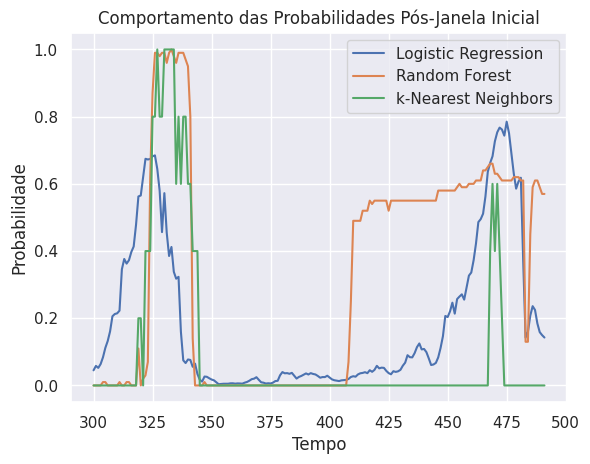

In [ ]:
# Obtendo as probabilidades previstas para o modelo de Regressão Logística
lr_probs = lr_model.predict_proba(X_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_scaled)[:, 1]
knn_probs = knn_model.predict_proba(X_scaled)[:, 1]

# Criando um vetor de índices para o período pós-janela inicial
post_initial_window = np.arange(300, len(data))

# Selecionando as probabilidades correspondentes ao período pós-janela inicial
lr_probs_post_window = lr_probs[post_initial_window]
rf_probs_post_window = rf_probs[post_initial_window]
knn_probs_post_window = knn_probs[post_initial_window]

# Criando um DataFrame para armazenar os dados de probabilidade
prob_data = pd.DataFrame({
    "Time": post_initial_window,
    "Logistic Regression": lr_probs_post_window,
    "RandomForest": rf_probs_post_window,
    "kNN": knn_probs_post_window
})

# Plotando o comportamento das probabilidades
plt.plot(prob_data["Time"], prob_data["Logistic Regression"], label="Logistic Regression")
plt.plot(prob_data["Time"], prob_data["RandomForest"], label="Random Forest")
plt.plot(prob_data["Time"], prob_data["kNN"], label="k-Nearest Neighbors")
plt.title("Comportamento das Probabilidades Pós-Janela Inicial")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade")
plt.legend()
plt.show()